Import Libraries

In [1]:
# Import libraries required for data handling, visualization,
# preprocessing, machine learning and model evaluation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

# Display plots directly inside Google Colab
%matplotlib inline

Download the Dermatology Dataset

In [2]:
# Download the Dermatology dataset from the UCI Machine Learning Repository

!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/dermatology/dermatology.data

# Check that the file has been downloaded
!ls -lh dermatology.data

-rw-r--r-- 1 root root 26K Sep 15 12:43 dermatology.data


Define Column Names

In [3]:
# Define the feature names provided for the Dermatology dataset

columns = [
    'erythema',
    'scaling',
    'definite_borders',
    'itching',
    'koebner_phenomenon',
    'polygonal_papules',
    'follicular_papules',
    'oral_mucosal_involvement',
    'knee_and_elbow_involvement',
    'scalp_involvement',
    'family_history',
    'melanin_incontinence',
    'eosinophils_infiltrate',
    'PNL_infiltrate',
    'fibrosis_of_the_papillary_dermis',
    'exocytosis',
    'acanthosis',
    'hyperkeratosis',
    'parakeratosis',
    'clubbing_of_the_rete_ridges',
    'elongation_of_the_rete_ridges',
    'thinning_of_the_suprapapillary_epidermis',
    'spongiform_pustule',
    'munro_microabcess',
    'focal_hypergranulosis',
    'disappearance_of_the_granular_layer',
    'vacuolisation_and_damage_of_basal_layer',
    'spongiosis',
    'saw_tooth_appearance_of_retes',
    'follicular_horn_plug',
    'perifollicular_parakeratosis',
    'inflammatory_monoluclear_infiltrate',
    'band_like_infiltrate',
    'age',
    'class'
]

Load the Dataset

In [4]:
# Load the dataset into a pandas DataFrame
# The dataset uses '?' to represent missing values

df = pd.read_csv(
    'dermatology.data',
    header=None,
    names=columns,
    na_values='?'
)

# Display the first five rows
df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw_tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3


Check Dataset Shape

In [5]:
# Check the number of rows and columns in the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 366
Number of columns: 35


Basic Dataset Information

In [6]:
# Display information about columns, data types and missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   erythema                                  366 non-null    int64  
 1   scaling                                   366 non-null    int64  
 2   definite_borders                          366 non-null    int64  
 3   itching                                   366 non-null    int64  
 4   koebner_phenomenon                        366 non-null    int64  
 5   polygonal_papules                         366 non-null    int64  
 6   follicular_papules                        366 non-null    int64  
 7   oral_mucosal_involvement                  366 non-null    int64  
 8   knee_and_elbow_involvement                366 non-null    int64  
 9   scalp_involvement                         366 non-null    int64  
 10  family_history                        

Check First and Last Rows

In [7]:
# Display the first five rows
print("First 5 rows:")
display(df.head())

# Display the last five rows
print("\nLast 5 rows:")
display(df.tail())

First 5 rows:


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw_tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3



Last 5 rows:


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw_tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_infiltrate,band_like_infiltrate,age,class
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25.0,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36.0,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28.0,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50.0,3
365,3,2,2,0,0,0,0,0,3,3,...,2,0,0,0,0,0,3,0,35.0,1


Summary Statistics

In [8]:
# Generate summary statistics for all numerical features

df.describe().T

,count,mean,std,min,25%,50%,75%,max
erythema,366.0,2.068306,0.664753,0.0,2.0,2.0,2.00,3.0
scaling,366.0,1.795082,0.701527,0.0,1.0,2.0,2.00,3.0
definite_borders,366.0,1.549180,0.907525,0.0,1.0,2.0,2.00,3.0
itching,366.0,1.366120,1.138299,0.0,0.0,1.0,2.00,3.0
koebner_phenomenon,366.0,0.633880,0.908016,0.0,0.0,0.0,1.00,3.0
polygonal_papules,366.0,0.448087,0.957327,0.0,0.0,0.0,0.00,3.0
follicular_papules,366.0,0.166667,0.570588,0.0,0.0,0.0,0.00,3.0
oral_mucosal_involvement,366.0,0.377049,0.834147,0.0,0.0,0.0,0.00,3.0
knee_and_elbow_involvement,366.0,0.614754,0.982979,0.0,0.0,0.0,1.00,3.0
scalp_involvement,366.0,0.519126,0.905639,0.0,0.0,0.0,1.00,3.0


Explicitly Calculate Mean, Median and Standard Deviation

In [9]:
# Select only feature columns and exclude the target variable
X_temp = df.drop('class', axis=1)

# Calculate important summary statistics
summary_stats = pd.DataFrame({
    'Mean': X_temp.mean(),
    'Median': X_temp.median(),
    'Standard Deviation': X_temp.std(),
    'Minimum': X_temp.min(),
    'Maximum': X_temp.max()
})

summary_stats

,Mean,Median,Standard Deviation,Minimum,Maximum
erythema,2.068306,2.0,0.664753,0.0,3.0
scaling,1.795082,2.0,0.701527,0.0,3.0
definite_borders,1.549180,2.0,0.907525,0.0,3.0
itching,1.366120,1.0,1.138299,0.0,3.0
koebner_phenomenon,0.633880,0.0,0.908016,0.0,3.0
polygonal_papules,0.448087,0.0,0.957327,0.0,3.0
follicular_papules,0.166667,0.0,0.570588,0.0,3.0
oral_mucosal_involvement,0.377049,0.0,0.834147,0.0,3.0
knee_and_elbow_involvement,0.614754,0.0,0.982979,0.0,3.0
scalp_involvement,0.519126,0.0,0.905639,0.0,3.0


Check Missing Values

In [10]:
# Count missing values in every column

missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values[missing_values > 0])

Missing values in each column:


,0
age,8


Total Missing Values

In [11]:
# Calculate the total number of missing values in the entire dataset

total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

Total missing values: 8


Task 1 — Data Acquisition & Exploration

Handle Missing Values

In [12]:
# Display the number of missing values in each column

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0
age,8


Replace Missing Values

In [13]:
# Calculate the median age
median_age = df['age'].median()

# Replace missing age values with the median age
df['age'] = df['age'].fillna(median_age)

# Check again for missing values
print("Total missing values after handling:",
      df.isnull().sum().sum())

Total missing values after handling: 0


Check for Duplicate Rows

In [14]:
# Count the number of duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


Remove Duplicates

In [15]:
# Remove duplicate rows from the dataset

df = df.drop_duplicates()

# Reset the row index after removing duplicates
df = df.reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (366, 35)


Check Data Types

In [16]:
# Display the data type of every column

df.dtypes

,0
erythema,int64
scaling,int64
definite_borders,int64
itching,int64
koebner_phenomenon,int64
polygonal_papules,int64
follicular_papules,int64
oral_mucosal_involvement,int64
knee_and_elbow_involvement,int64
scalp_involvement,int64


Convert Features to Numeric

In [17]:
# Convert all columns to numeric values
# Invalid values will be converted to NaN

for column in df.columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

# Check data types again
df.dtypes

,0
erythema,int64
scaling,int64
definite_borders,int64
itching,int64
koebner_phenomenon,int64
polygonal_papules,int64
follicular_papules,int64
oral_mucosal_involvement,int64
knee_and_elbow_involvement,int64
scalp_involvement,int64


Check Missing Values Again

In [18]:
# Check whether any missing values were created during conversion

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


Check Target/Class Distribution

In [19]:
# Count the number of samples in each target class

class_counts = df['class'].value_counts().sort_index()

print("Number of samples in each class:")
display(class_counts)

Number of samples in each class:


,count
class,
1,112
2,61
3,72
4,49
5,52
6,20


Class Distribution Visualization

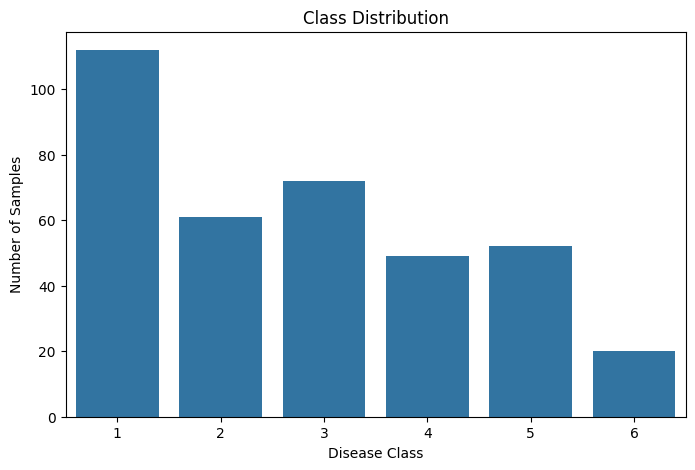

In [20]:
# Visualize the number of samples belonging to each class

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='class'
)

plt.title('Class Distribution')
plt.xlabel('Disease Class')
plt.ylabel('Number of Samples')

plt.show()

Class Distribution in Percentage

In [21]:
# Calculate the percentage of samples belonging to each class

class_percentage = (
    df['class']
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("Class distribution (%):")
display(class_percentage.round(2))

Class distribution (%):


,proportion
class,
1,30.60
2,16.67
3,19.67
4,13.39
5,14.21
6,5.46


Feature Histograms

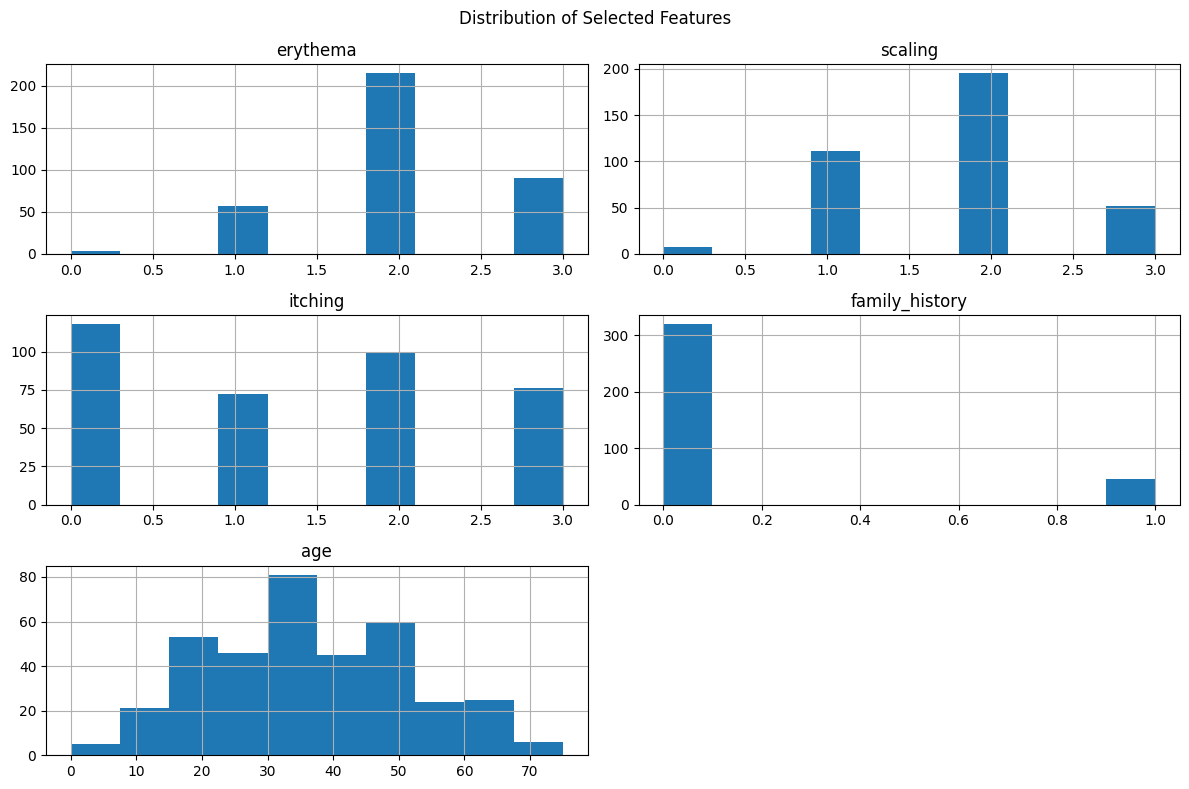

In [22]:
# Select a few features for visualization

selected_features = [
    'erythema',
    'scaling',
    'itching',
    'family_history',
    'age'
]

# Create histograms for the selected features
df[selected_features].hist(
    figsize=(12, 8),
    bins=10
)

plt.suptitle('Distribution of Selected Features')
plt.tight_layout()

plt.show()

Box Plots for Outlier Detection

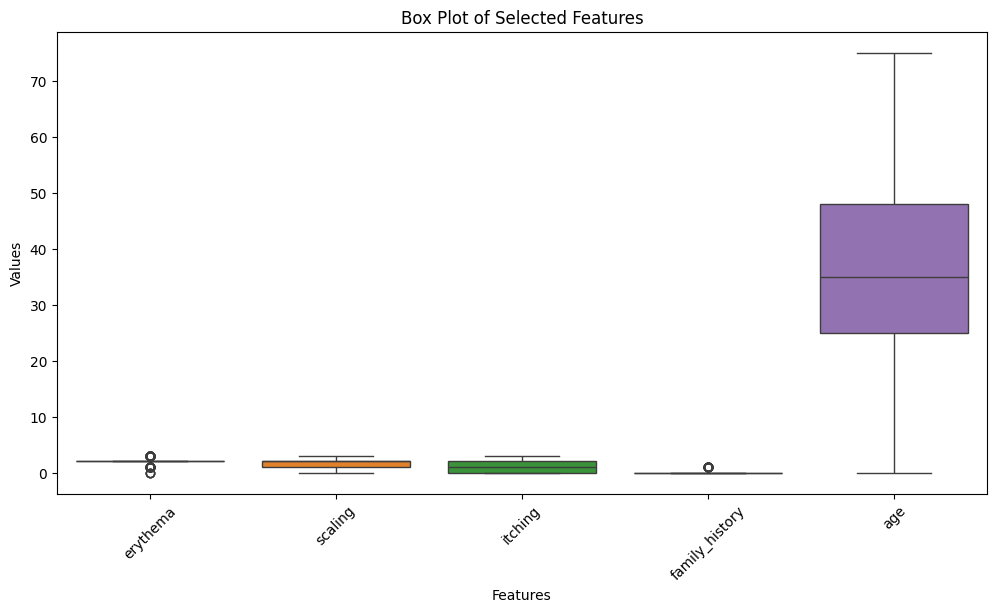

In [23]:
# Select numerical features for outlier visualization

selected_features = [
    'erythema',
    'scaling',
    'itching',
    'family_history',
    'age'
]

# Create box plots
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[selected_features]
)

plt.title('Box Plot of Selected Features')
plt.xlabel('Features')
plt.ylabel('Values')

plt.xticks(rotation=45)

plt.show()

Detect Outliers Using IQR

In [24]:
# Select only the feature columns
features = df.drop('class', axis=1)

# Calculate Q1 and Q3
Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)

# Calculate the Interquartile Range
IQR = Q3 - Q1

# Define the lower and upper limits for potential outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count potential outliers for each feature
outlier_counts = (
    ((features < lower_bound) | (features > upper_bound))
    .sum()
)

print("Potential outliers in each feature:")
display(outlier_counts[outlier_counts > 0])

Potential outliers in each feature:


,0
erythema,151
koebner_phenomenon,18
polygonal_papules,69
follicular_papules,33
oral_mucosal_involvement,67
knee_and_elbow_involvement,23
scalp_involvement,16
family_history,46
melanin_incontinence,70
eosinophils_infiltrate,42


Correlation Heatmap

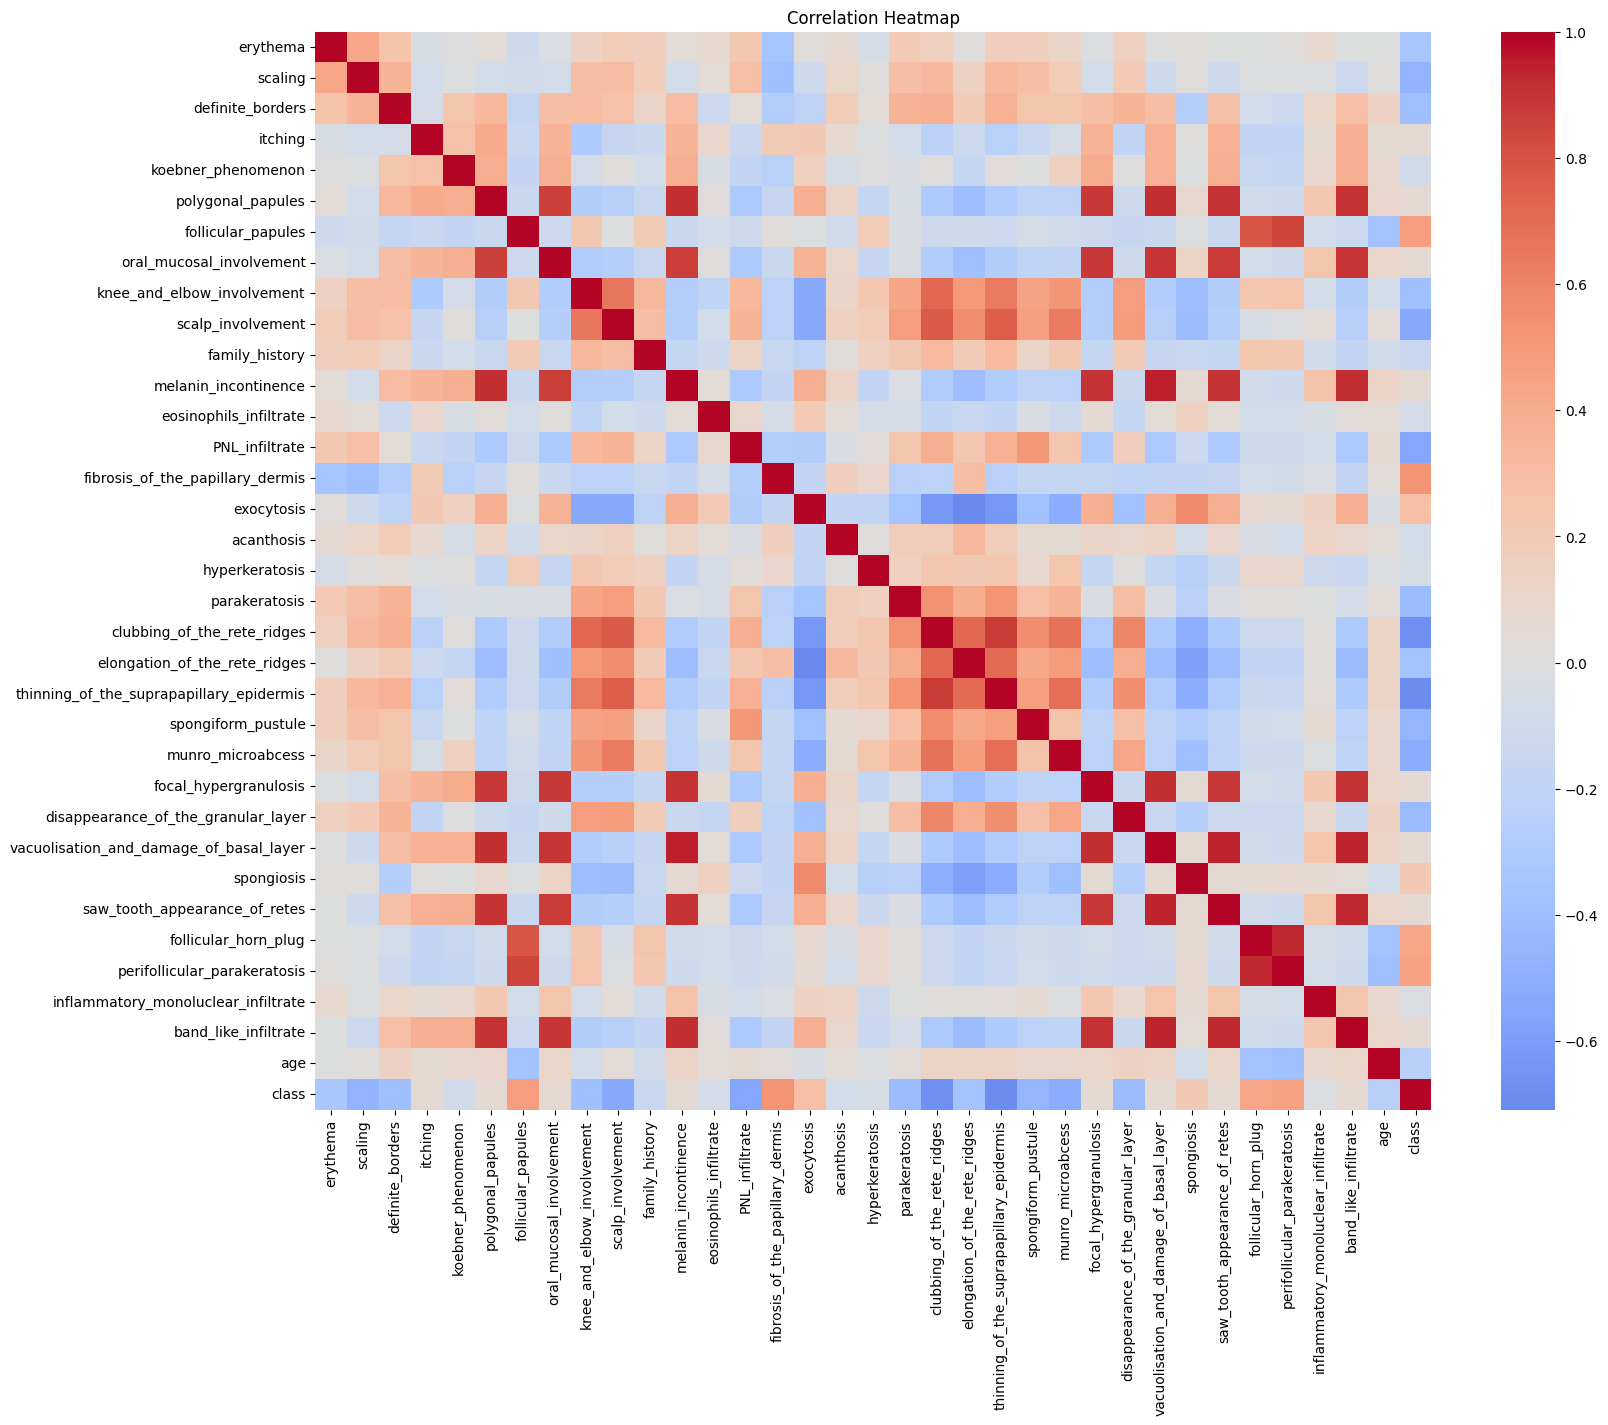

In [26]:
# Calculate the correlation matrix for all numerical variables

correlation_matrix = df.corr()

# Visualize the correlation matrix
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')

plt.show()

Correlation with Target

In [27]:
# Calculate correlation between every feature and the target class

target_correlation = (
    df.corr()['class']
    .drop('class')
    .sort_values(ascending=False)
)

display(target_correlation)

,class
fibrosis_of_the_papillary_dermis,0.526976
follicular_papules,0.477813
perifollicular_parakeratosis,0.457025
follicular_horn_plug,0.431972
exocytosis,0.283433
spongiosis,0.213401
focal_hypergranulosis,0.063241
saw_tooth_appearance_of_retes,0.060444
polygonal_papules,0.057785
melanin_incontinence,0.057394


Final Dataset Check

In [28]:
# Display the final shape of the cleaned dataset
print("Final dataset shape:", df.shape)

# Check for missing values
print("Total missing values:", df.isnull().sum().sum())

# Check for duplicates
print("Total duplicate rows:", df.duplicated().sum())

# Display the first five rows
display(df.head())

Final dataset shape: (366, 35)
Total missing values: 0
Total duplicate rows: 0


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw_tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3


TASK 2 — Data Preprocessing

In [29]:
#Separate X and y + Encode Target
# Separate features (X) and target variable (y)
X = df.drop('class', axis=1)
y = df['class']

# Encode the six disease classes into numerical labels (0 to 5)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Feature shape:", X.shape)
print("Target shape:", y_encoded.shape)
print("Encoded classes:", np.unique(y_encoded))

Feature shape: (366, 34)
Target shape: (366,)
Encoded classes: [0 1 2 3 4 5]


Train-Test Split

In [30]:
# Split the data into 80% training and 20% testing data
# stratify keeps the proportion of each class similar in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (292, 34)
Testing data: (74, 34)


Standardize Features

In [31]:
# Standardize the features so that they have a similar scale
# The scaler is fitted only on training data to prevent data leakage

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)


Scaled training data: (292, 34)
Scaled testing data: (74, 34)


Verify Preprocessing

In [32]:
# Verify that the class distribution is maintained after stratified splitting

print("Training class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

# Check the average of scaled training features
print("\nMean of scaled features (approximately 0):",
      round(X_train_scaled.mean(), 4))

Training class distribution:
0    89
1    49
2    57
3    39
4    42
5    16
Name: count, dtype: int64

Testing class distribution:
0    23
1    12
2    15
3    10
4    10
5     4
Name: count, dtype: int64

Mean of scaled features (approximately 0): 0.0


MODEL TRAINING & EVALUATION

In [33]:
#Create and Train All 4 Models
# Create four different machine learning models for multiclass classification

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# Train each model using the standardized training data
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(name, "trained successfully.")

Logistic Regression trained successfully.
KNN trained successfully.
Random Forest trained successfully.
SVM trained successfully.


Make Predictions and Compare Basic Metrics

In [34]:
# Store the evaluation results of all models
results = []

for name, model in models.items():

    # Predict disease classes for the unseen test data
    y_pred = model.predict(X_test_scaled)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Store the results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Convert results into a DataFrame
results_df = pd.DataFrame(results)

# Display results
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9595,0.9688,0.9595,0.9606
1,KNN,0.9054,0.9193,0.9054,0.9081
2,Random Forest,0.9595,0.9607,0.9595,0.9595
3,SVM,0.9730,0.9775,0.9730,0.9730


Classification Reports

In [35]:
# Display precision, recall and F1-score for every disease class

for name, model in models.items():

    # Generate predictions
    y_pred = model.predict(X_test_scaled)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                'Psoriasis',
                'Seboreic Dermatitis',
                'Lichen Planus',
                'Pityriasis Rosea',
                'Chronic Dermatitis',
                'Pityriasis Rubra Pilaris'
            ]
        )
    )


Logistic Regression
                          precision    recall  f1-score   support

               Psoriasis       1.00      1.00      1.00        23
     Seboreic Dermatitis       1.00      0.83      0.91        12
           Lichen Planus       1.00      0.93      0.97        15
        Pityriasis Rosea       0.77      1.00      0.87        10
      Chronic Dermatitis       1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4

                accuracy                           0.96        74
               macro avg       0.96      0.96      0.96        74
            weighted avg       0.97      0.96      0.96        74


KNN
                          precision    recall  f1-score   support

               Psoriasis       1.00      0.96      0.98        23
     Seboreic Dermatitis       0.80      0.67      0.73        12
           Lichen Planus       1.00      0.93      0.97        15
        Pityriasis Rosea       0.64      0.90 

Confusion Matrices

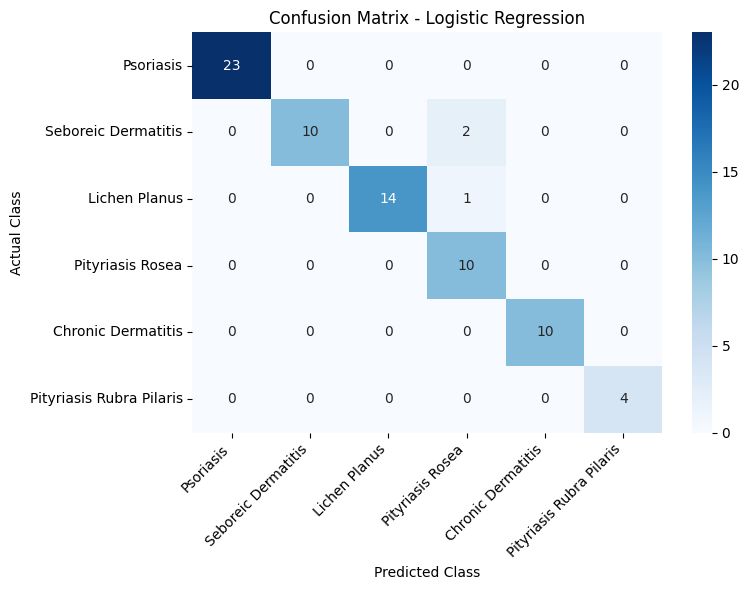

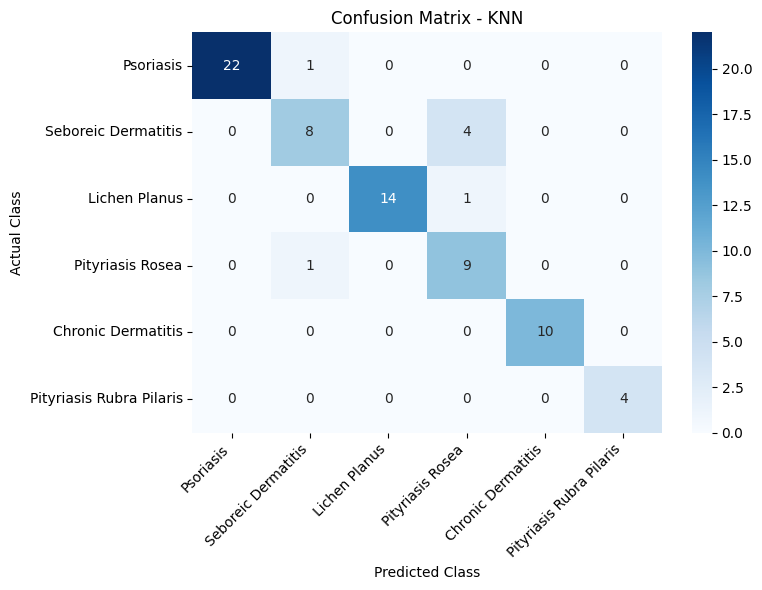

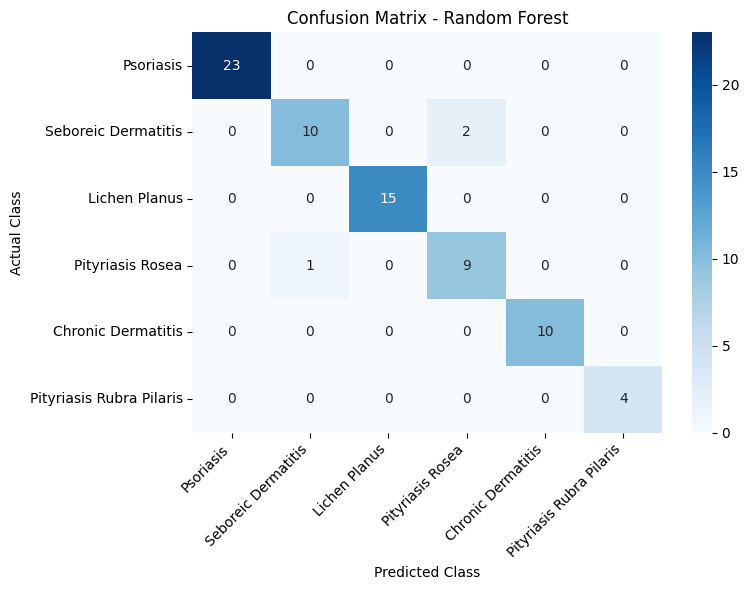

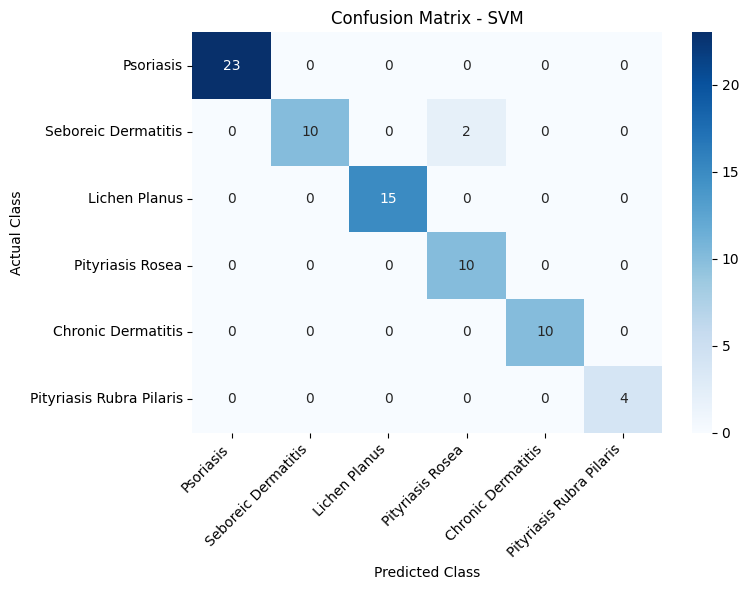

In [36]:
# Visualize the confusion matrix for each trained model

class_names = [
    'Psoriasis',
    'Seboreic Dermatitis',
    'Lichen Planus',
    'Pityriasis Rosea',
    'Chronic Dermatitis',
    'Pityriasis Rubra Pilaris'
]

for name, model in models.items():

    # Generate predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

Calculate AUC for All Models

In [37]:
# Calculate the multiclass AUC score for each model

auc_results = []

for name, model in models.items():

    # Get probability scores for every class
    y_prob = model.predict_proba(X_test_scaled)

    # Calculate multiclass ROC-AUC using One-vs-Rest strategy
    auc_score = roc_auc_score(
        y_test,
        y_prob,
        multi_class='ovr',
        average='weighted'
    )

    auc_results.append({
        'Model': name,
        'AUC': auc_score
    })

# Display AUC scores
auc_df = pd.DataFrame(auc_results)

auc_df.round(4)

,Model,AUC
0,Logistic Regression,0.9991
1,KNN,0.9871
2,Random Forest,0.9985
3,SVM,0.9983


Plot Multiclass ROC Curves

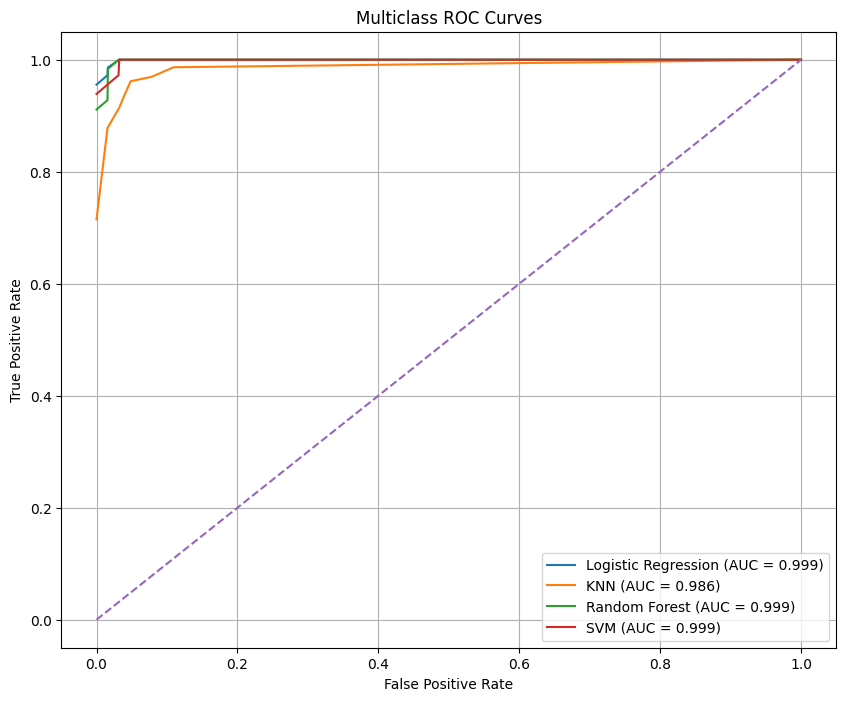

In [38]:
# Plot ROC curves for each model using the One-vs-Rest approach

from sklearn.preprocessing import label_binarize

# Convert class labels into binary form for ROC calculation
y_test_binary = label_binarize(
    y_test,
    classes=np.arange(len(class_names))
)

plt.figure(figsize=(10, 8))

for name, model in models.items():

    # Get probability predictions
    y_prob = model.predict_proba(X_test_scaled)

    # Calculate ROC curve for each class
    fpr = {}
    tpr = {}

    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(
            y_test_binary[:, i],
            y_prob[:, i]
        )

    # Calculate macro-average ROC curve
    all_fpr = np.unique(
        np.concatenate([fpr[i] for i in range(len(class_names))])
    )

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(len(class_names)):
        mean_tpr += np.interp(
            all_fpr,
            fpr[i],
            tpr[i]
        )

    mean_tpr /= len(class_names)

    # Calculate macro AUC
    macro_auc = auc(all_fpr, mean_tpr)

    # Plot the model's macro-average ROC curve
    plt.plot(
        all_fpr,
        mean_tpr,
        label=f'{name} (AUC = {macro_auc:.3f})'
    )

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves')
plt.legend()
plt.grid()
plt.show()

Final Model Comparison

In [39]:
# Add AUC scores to the existing model comparison table

results_df = results_df.merge(
    auc_df,
    on='Model'
)

# Sort models by F1-score
results_df = results_df.sort_values(
    by='F1-Score',
    ascending=False
)

print("Final Model Comparison:")
display(results_df.round(4))

Final Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,AUC
3,SVM,0.9730,0.9775,0.9730,0.9730,0.9983
0,Logistic Regression,0.9595,0.9688,0.9595,0.9606,0.9991
2,Random Forest,0.9595,0.9607,0.9595,0.9595,0.9985
1,KNN,0.9054,0.9193,0.9054,0.9081,0.9871


Identify the Best Model

In [40]:
# Identify the model with the highest F1-score

best_model = results_df.iloc[0]

print("Best Model:", best_model['Model'])
print("Accuracy:", round(best_model['Accuracy'], 4))
print("Precision:", round(best_model['Precision'], 4))
print("Recall:", round(best_model['Recall'], 4))
print("F1-Score:", round(best_model['F1-Score'], 4))
print("AUC:", round(best_model['AUC'], 4))

Best Model: SVM
Accuracy: 0.973
Precision: 0.9775
Recall: 0.973
F1-Score: 0.973
AUC: 0.9983
